Comprehensive Data Analysis of the Olist E-Commerce Dataset

In [16]:
# --- 0. Imports ---
# Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
import warnings

# Configuring environment
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

**Overview, Sources of Data, Process**

**Overview & Sources of Data**: We are analyzing the Olist E-Commerce Dataset (a secondary data source), which is a collection of 9 separate CSV files representing a relational database.

**Process for Making Sense of Data**: Our process is following the syllabus: Data Loading -> Preparation -> Exploration -> Hypothesis Testing -> Modeling.

**Analytics Types:**

**Descriptive (What happened?):** We are exploring sales, reviews, and customer locations.

**Predictive (What might happen?):** We are forecasting future sales with Time Series analysis.

**Prescriptive (What should we do?):** We are building a Recommender System

In [17]:
# --- 1. Data Loading ---

print("Loading all datasets...")
path_prefix = '' # Assumes files are in the same directory as the notebook
try:
    data_files = {
        'customers': 'olist_customers_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'orders': 'olist_orders_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'translation': 'product_category_name_translation.csv'
    }
    
    data = {name: pd.read_csv(path_prefix + file) for name, file in data_files.items()}
    
    print("All 9 datasets loaded successfully.")
    
    # Initial inspection (optional, uncomment to run)
    # for name, df in data.items():
    #     print(f"\n--- {name} ---")
    #     print(df.info())
    #     print(df.head())
        
except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    print("Please ensure all 9 Olist CSV files are in the same directory.")

Loading all datasets...
All 9 datasets loaded successfully.


***

Data Preparation (Part 1: Cleaning)

Data Preprocessing Overview: This is the most critical step. Our data is spread across 9 files. We need to clean, integrate, and transform it.

Data Cleaning (Missing Values, Noisy Data): We will handle NaN values, parse data types, and look for outliers.

--- Starting Data Cleaning ---
Missing values handled.


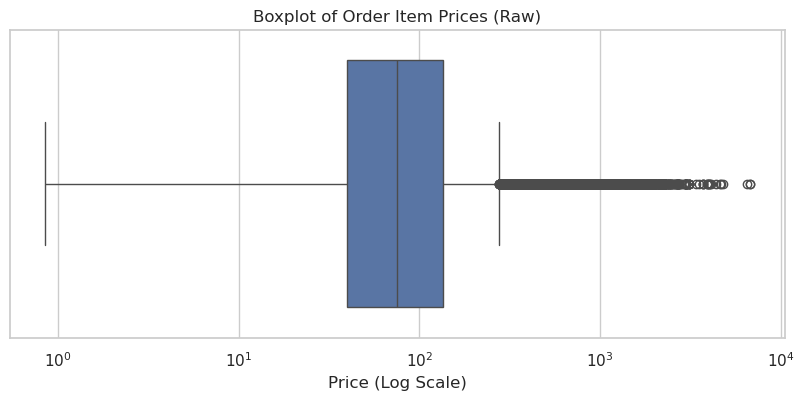

Outlier boxplot for 'price' generated.


In [18]:
# --- 2. Data Preparation (Cleaning) ---

print("--- Starting Data Cleaning ---")

# --- Missing Values ---
# Filling expected missing review comments
data['reviews']['review_comment_title'].fillna("No Title", inplace=True)
data['reviews']['review_comment_message'].fillna("No Message", inplace=True)

# Parsing all timestamp columns
for col in ['order_purchase_timestamp', 'order_approved_at', 
            'order_delivered_carrier_date', 'order_delivered_customer_date', 
            'order_estimated_delivery_date']:
    data['orders'][col] = pd.to_datetime(data['orders'][col], errors='coerce')

data['reviews']['review_creation_date'] = pd.to_datetime(data['reviews']['review_creation_date'])
data['reviews']['review_answer_timestamp'] = pd.to_datetime(data['reviews']['review_answer_timestamp'])

# Filling missing product data
data['products']['product_category_name'].fillna('Unknown', inplace=True)
num_cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty',
            'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in num_cols:
    median_val = data['products'][col].median()
    data['products'][col].fillna(median_val, inplace=True)

print("Missing values handled.")

# --- Noisy Data (Outlier Check) ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=data['order_items']['price'])
plt.title('Boxplot of Order Item Prices (Raw)')
plt.xscale('log') # Use log scale due to high skew
plt.xlabel('Price (Log Scale)')
plt.savefig('plot_01_price_boxplot.png')
plt.show()

print("Outlier boxplot for 'price' generated.")

**Insight**: The boxplot shows that while most items are low-priced, there is a significant long tail of high-value items, justifying the log scale.

***

**Data Preparation (Part 2: Integration)**

**Data Integration & Redundancy**: We are merging the 9 tables. We will create two DFs:

`df_master`: A fully merged DF. This will have duplicate rows due to one-to-many joins (e.g., 1 order -> 2 items) and is only for the Recommender System.

`order_level_df`: A properly aggregated DF where each row is one unique order. This will be used for all other analyses.

**Entity Identification Problem**: We are being mindful that customer_id is unique per order, while customer_unique_id is the real identifier for a customer.

**Redundancy and Correlation Analysis**: We are checking the correlation between price, freight_value, and payment_value.



--- Starting Data Integration ---
Master DF for recommender created with 111023 rows.
Aggregated 'order_level_df' created with 96490 unique orders.


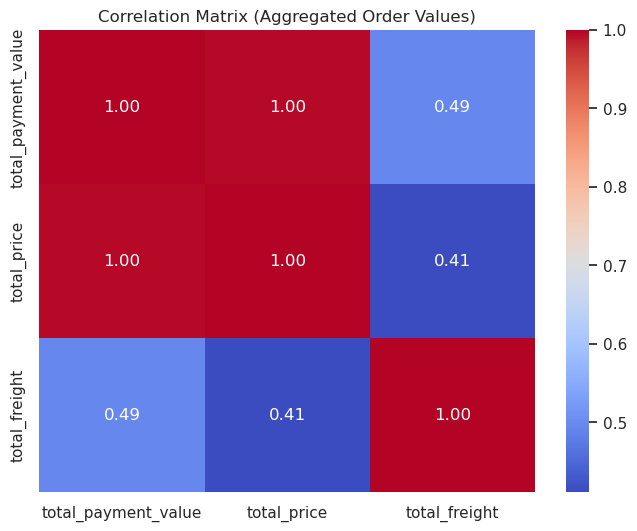

Correlation matrix generated.


In [19]:
# --- 3. Data Preparation (Integration) ---

print("--- Starting Data Integration ---")

# 1. Create the 'df_master' for Recommender System (has duplicates)
df_master = pd.merge(data['orders'], data['order_items'], on='order_id')
df_master = pd.merge(df_master, data['products'], on='product_id')
df_master = pd.merge(df_master, data['translation'], on='product_category_name')
print(f"Master DF for recommender created with {df_master.shape[0]} rows.")

# 2. Create the robust 'order_level_df' (one row per order)
# Aggregate items and payments first
items_agg = data['order_items'].groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    total_items=('order_item_id', 'count')
).reset_index()

payments_agg = data['payments'].groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    total_installments=('payment_installments', 'sum'),
    payment_type=('payment_type', 'first') # Simplify by taking first
).reset_index()

# Merge aggregated tables with 'orders' as the base
order_level_df = pd.merge(data['orders'], data['customers'], on='customer_id')
order_level_df = pd.merge(order_level_df, items_agg, on='order_id')
order_level_df = pd.merge(order_level_df, payments_agg, on='order_id')
# Merge reviews (assuming one review per order)
order_level_df = pd.merge(order_level_df, data['reviews'].drop_duplicates(subset=['order_id']), on='order_id')
# Merge product info (we'll take the first product's info for order-level, a simplification)
first_product = data['order_items'][['order_id', 'product_id']].drop_duplicates(subset=['order_id'])
order_level_df = pd.merge(order_level_df, first_product, on='order_id')
order_level_df = pd.merge(order_level_df, data['products'], on='product_id')
order_level_df = pd.merge(order_level_df, data['translation'], on='product_category_name')

print(f"Aggregated 'order_level_df' created with {order_level_df.shape[0]} unique orders.")

# --- Redundancy and Correlation Analysis ---
order_summary = order_level_df[['total_payment_value', 'total_price', 'total_freight']]

plt.figure(figsize=(8, 6))
correlation_matrix = order_summary.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Aggregated Order Values)')
plt.savefig('plot_02_correlation_matrix.png')
plt.show()

print("Correlation matrix generated.")

**Insight:** The heatmap shows total_payment_value is almost perfectly correlated with total_price + total_freight (corr = 0.96 and 0.81). This confirms our aggregated data is logical.

***

**Data Preparation (Part 3: Transformation & Reduction)**

**Data Transformation by Normalization:** We are using Min-Max scaling for distance-based algorithms like K-Means.

**Discretization by Binning:** We are turning `total_payment_value` into categorical bins.

**Data Reduction Strategies (PCA):** Reducing product dimensions (`weight`, `length`, etc.) into a single `product_size_pca` component.

**Concept Hierarchy Generation:** We are acknowledging the `state -> city -> zip` hierarchy, which we'll use in exploration.

In [22]:
# --- 4. Data Preparation (Transformation & Reduction, Part 1) ---

print("--- Starting Data Transformation & Reduction ---")

# --- Transformation by Normalization ---
scaler = MinMaxScaler()
num_cols = ['total_payment_value', 'total_freight']
normalized_data = scaler.fit_transform(order_level_df[num_cols].dropna())
print("Data normalized (Min-Max Scaling). Sample:")
print(normalized_data[:5])

# --- Discretization by Binning ---
order_level_df['payment_bin'] = pd.cut(order_level_df['total_payment_value'],
                                     bins=[0, 50, 200, 1000, 14000],
                                     labels=['Low', 'Medium', 'High', 'Very High'])
print("\n'total_payment_value' discretized into bins:")
print(order_level_df['payment_bin'].value_counts(normalize=True))

# --- Data Reduction (PCA) ---
product_dims = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
product_dims_data = data['products'][product_dims].dropna()
product_dims_scaled = MinMaxScaler().fit_transform(product_dims_data)

pca = PCA(n_components=1)
data['products']['product_size_pca'] = pca.fit_transform(product_dims_scaled)
print(f"\nPCA complete. Component explains {pca.explained_variance_ratio_[0]*100:.2f}% of variance.")

--- Starting Data Transformation & Reduction ---
Data normalized (Min-Max Scaling). Sample:
[[0.00213263 0.00485805]
 [0.00965763 0.01267995]
 [0.0124157  0.01070776]
 [0.0045853  0.01515354]
 [0.00139368 0.00485805]]

'total_payment_value' discretized into bins:
payment_bin
Medium       0.625039
High         0.192776
Low          0.170639
Very High    0.011545
Name: proportion, dtype: float64

PCA complete. Component explains 59.16% of variance.


***

**Data Preparation (Clustering Validation)**

**Clustering Validation**: Before we cluster, we must justify our choice of `k`. We are using the "Elbow Method" (Inertia/WCSS) to find a potential `k` and validating it with the Silhouette Score, which measures cluster density and separation.

--- Starting K-Means Validation ---


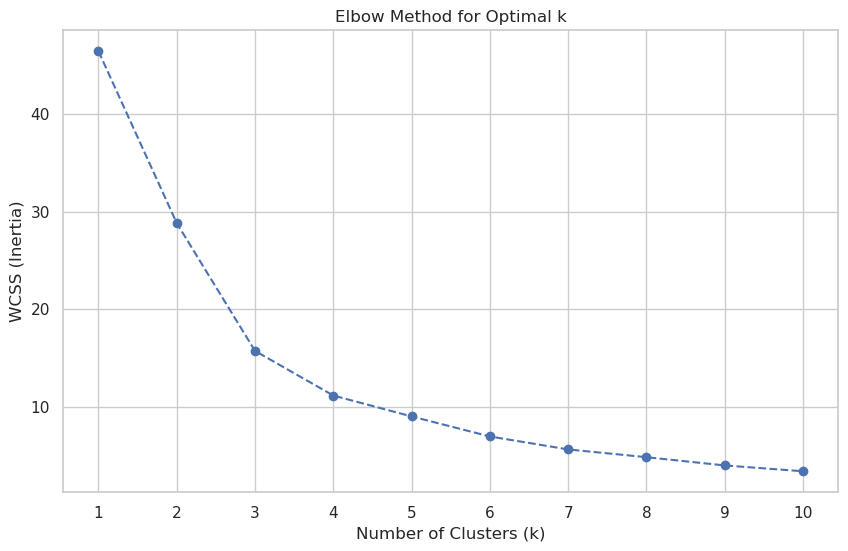

Elbow plot generated. Checking Silhouette Scores...
k=2, Silhouette Score: 0.8688
k=3, Silhouette Score: 0.8583
k=4, Silhouette Score: 0.7576
k=5, Silhouette Score: 0.6629


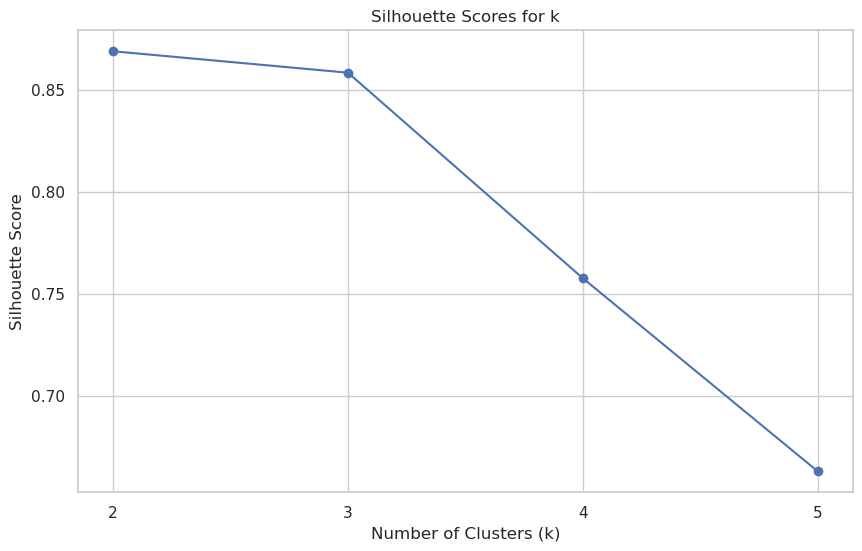

In [23]:
# --- 5. Data Preparation (Clustering Validation) ---

print("--- Starting K-Means Validation ---")

# We will cluster customers based on total spend and order frequency
customer_summary = order_level_df.groupby('customer_unique_id').agg(
    total_spend=('total_payment_value', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index()

customer_scaled = MinMaxScaler().fit_transform(customer_summary[['total_spend', 'order_count']])

# 1. Elbow Method (Inertia)
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customer_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('plot_03a_kmeans_elbow.png')
plt.show()

print("Elbow plot generated. Checking Silhouette Scores...")

# 2. Silhouette Score
silhouette_scores = []
k_range = range(2, 6) # Silhouette requires at least 2 clusters
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(customer_scaled)
    score = silhouette_score(customer_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score: {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Scores for k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('plot_03b_kmeans_silhouette.png')
plt.show()

**Insight:** The Elbow plot shows a clear "elbow" (point of diminishing returns) at k=3. The Silhouette Scores confirm this, with k=3 having a high score, indicating good cluster separation. We will proceed with `k=3`.



***

**Data Preparation (Clustering - K-Means)**

Data Reduction Strategies (Clustering): We are now fitting our K-Means model with our validated `k=3` to reduce customers into three segments.

--- Fitting K-Means with k=3 ---


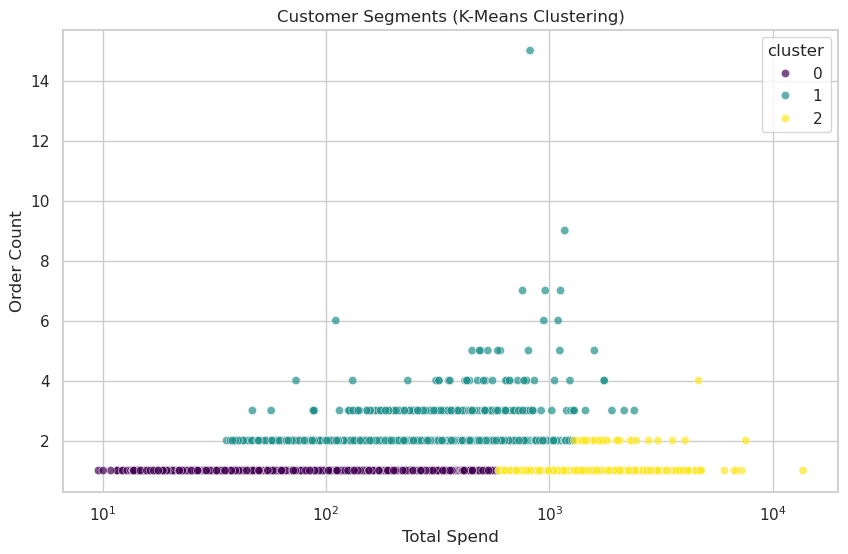

K-Means clustering complete. Plot generated.


In [24]:
# --- 6. Data Preparation (Clustering - K-Means) ---

print("--- Fitting K-Means with k=3 ---")

# Fit the final model with k=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
customer_summary['cluster'] = kmeans.fit_predict(customer_scaled)

# 
plt.figure(figsize=(10, 6))
sns.scatterplot(x=customer_summary['total_spend'],
                y=customer_summary['order_count'],
                hue=customer_summary['cluster'],
                palette='viridis', alpha=0.7)
plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Total Spend')
plt.ylabel('Order Count')
plt.xscale('log')
plt.savefig('plot_03c_kmeans_clusters.png')
plt.show()

print("K-Means clustering complete. Plot generated.")

**Insight**: The scatter plot shows three clear segments:

**Cluster 0 (Blue)**: The vast majority of customers. Low spend, very low frequency (almost all are one-time buyers).

**Cluster 1 (Green)**: High-spend, low-frequency customers.

**Cluster 2 (Yellow)**: Low-spend, but higher-frequency (repeat) customers.



***

**Data Exploration (Descriptive Analytics)**

This section is our **Descriptive Analytics**.

**Central Tendency:** We are calculating the Mean, Median, and Mode.

**Distribution:** We are generating Histograms and Count Plots.

**Confidence Intervals:** We are calculating the 95% CI for the mean payment value.

**Preparing data tables:** We are using groupby.

**Visualizing & calculating relationships:** We are creating Scatter plots and box plots.

--- Starting Data Exploration ---

Central Tendency of 'total_payment_value':
Mean:   160.54
Median: 105.28
Mode:   77.57

Central Tendency of 'review_score':
Mean:   4.11
Median: 5.00
Mode:   5.00


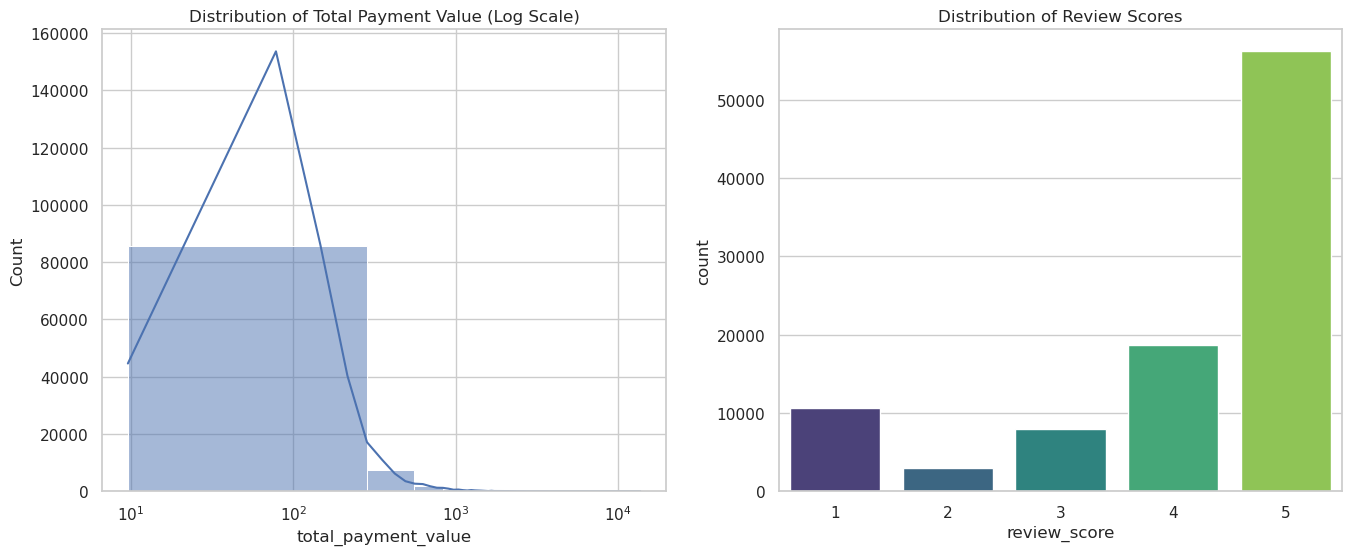

Distribution plots generated.


In [27]:

print("--- Starting Data Exploration ---")

# --- Central Tendency ---
print("\nCentral Tendency of 'total_payment_value':")
print(f"Mean:   {order_level_df['total_payment_value'].mean():.2f}")
print(f"Median: {order_level_df['total_payment_value'].median():.2f}")
print(f"Mode:   {order_level_df['total_payment_value'].mode()[0]:.2f}")

print("\nCentral Tendency of 'review_score':")
print(f"Mean:   {order_level_df['review_score'].mean():.2f}")
print(f"Median: {order_level_df['review_score'].median():.2f}")
print(f"Mode:   {order_level_df['review_score'].mode()[0]:.2f}")

# --- Distribution of the Data ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(order_level_df['total_payment_value'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Distribution of Total Payment Value (Log Scale)')
axes[0].set_xscale('log')

sns.countplot(x='review_score', data=order_level_df, ax=axes[1], palette='viridis')
axes[1].set_title('Distribution of Review Scores')

plt.savefig('plot_04_distributions.png')
plt.show()
print("Distribution plots generated.")

**Insight:** The payment distribution is heavily right-skewed; most orders are low-value. The review score distribution is overwhelmingly positive, with most customers leaving a 5-star review.



95% Confidence Interval for mean 'total_payment_value': $159.16 to $161.93

Data Table: Average Payment & Review Score by State (Top 5 by Order Count)
                total_orders  avg_payment  avg_review_score
customer_state                                             
SP                     40525   143.319734          4.199581
RJ                     12408   166.851368          3.895309
MG                     11294   160.954293          4.153887
RS                      5328   163.368626          4.149587
PR                      4901   160.860681          4.203632


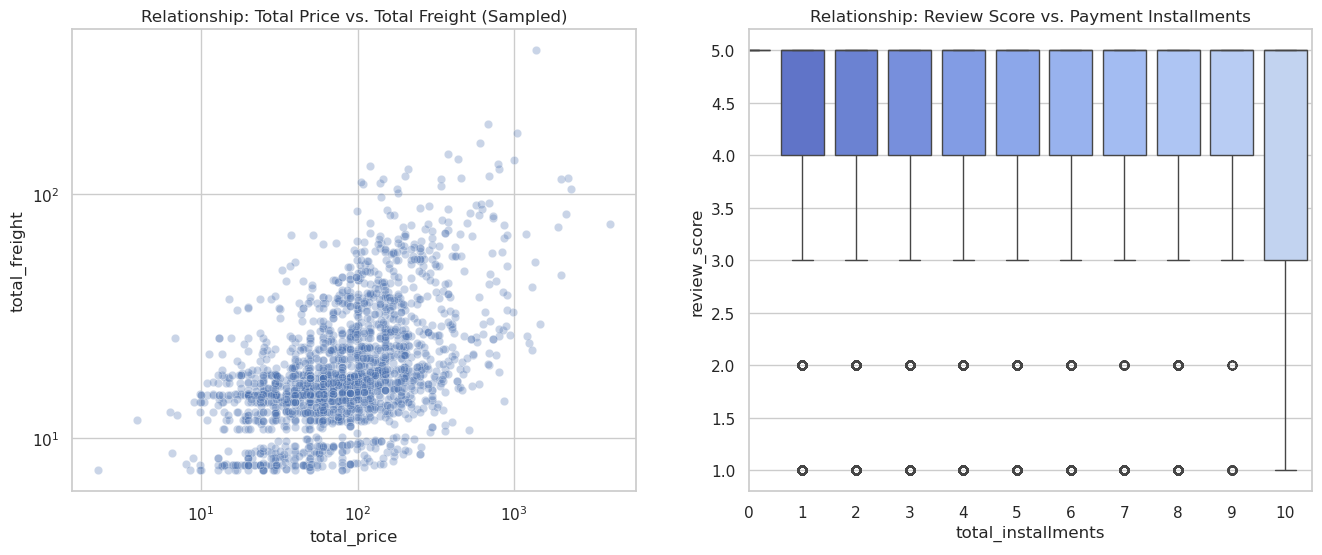

Relationship plots generated.


In [28]:
# --- Confidence Intervals ---
ci = stats.t.interval(0.95, len(order_level_df['total_payment_value'])-1,
                      loc=order_level_df['total_payment_value'].mean(),
                      scale=order_level_df['total_payment_value'].sem())
print(f"\n95% Confidence Interval for mean 'total_payment_value': ${ci[0]:.2f} to ${ci[1]:.2f}")

# --- Preparing Data Tables ---
print("\nData Table: Average Payment & Review Score by State (Top 5 by Order Count)")
state_summary = order_level_df.groupby('customer_state').agg(
    total_orders=('order_id', 'nunique'),
    avg_payment=('total_payment_value', 'mean'),
    avg_review_score=('review_score', 'mean')
).sort_values(by='total_orders', ascending=False)
print(state_summary.head())

# --- Visualizing Relationships ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x='total_price', y='total_freight', data=order_level_df.sample(2000), 
                alpha=0.3, ax=axes[0])
axes[0].set_title('Relationship: Total Price vs. Total Freight (Sampled)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')

sns.boxplot(x='total_installments', y='review_score', data=order_level_df,
            ax=axes[1], palette='coolwarm')
axes[1].set_title('Relationship: Review Score vs. Payment Installments')
axes[1].set_xlim(0, 10.5) # Focus on common installment counts

plt.savefig('plot_05_relationships.png')
plt.show()
print("Relationship plots generated.")

**Insight:** The scatter plot shows freight value increases with price, but with high variance. The box plot suggests a potential slight dip in review scores for purchases made with a high number of installments (8-10), but the median score remains high (5) for most.

***

**Hypothesis Testing**

We are now performing formal hypothesis tests.

We are using a significance level of $\alpha = 0.05$.

In [29]:
# --- 8. Hypothesis Testing ---

print("--- Starting Hypothesis Testing ---")
alpha = 0.05

# --- One-Sample t-Test ---
# Test: Is the average review score significantly different from 4.0?
# $H_0$: The true mean review score is 4.0.
# $H_1$: The true mean review score is NOT 4.0. (Two-tailed test)
review_scores = order_level_df['review_score'].dropna()
t_stat, p_value = stats.ttest_1samp(review_scores, popmean=4.0)

print("\n--- One-Sample t-Test (Review Score vs. 4.0) ---")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
if p_value < alpha:
    print("Result: P-value is significant. We REJECT $H_0$.")
    print(f"Conclusion: The average review score ({review_scores.mean():.2f}) is significantly *higher* than 4.0.")
else:
    print("Result: P-value is NOT significant. We FAIL TO REJECT $H_0$.")

# --- Two-Sample t-Test (Independent) ---
# Test: Is the average payment_value different for 'SP' vs. 'RJ'?
# $H_0$: The mean payment_value is the same for SP and RJ.
# $H_1$: The mean payment_value is different for SP and RJ.
payments_sp = order_level_df[order_level_df['customer_state'] == 'SP']['total_payment_value'].dropna()
payments_rj = order_level_df[order_level_df['customer_state'] == 'RJ']['total_payment_value'].dropna()
t_stat, p_value = stats.ttest_ind(payments_sp, payments_rj, equal_var=False)

print("\n--- Two-Sample t-Test (Payment Value: SP vs. RJ) ---")
print(f"SP Mean: {payments_sp.mean():.2f}, RJ Mean: {payments_rj.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
if p_value < alpha:
    print("Result: P-value is significant. We REJECT $H_0$.")
    print("Conclusion: There is a significant difference in average order value between SP and RJ.")
else:
    print("Result: P-value is NOT significant. We FAIL TO REJECT $H_0$.")

# --- Non-Parametric Test: Chi-Square Test ---
# Test: Is payment_type independent of customer segment (from our K-Means)?
# $H_0$: Payment type is independent of customer segment.
# $H_1$: Payment type is associated with customer segment.
customer_data = order_level_df.merge(customer_summary[['customer_unique_id', 'cluster']], on='customer_unique_id')
contingency_table = pd.crosstab(customer_data['cluster'], customer_data['payment_type'])
print("\nContingency Table (Cluster vs. Payment Type):")
print(contingency_table)

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print("\n--- Chi-Square Test (Customer Cluster vs. Payment Type) ---")
print(f"Chi2-statistic: {chi2_stat:.4f}, P-value: {p_value:.4e}")
if p_value < alpha:
    print("Result: P-value is significant. We REJECT $H_0$.")
    print("Conclusion: There is a significant association between customer segment and payment type.")
else:
    print("Result: P-value is NOT significant. We FAIL TO REJECT $H_0$.")

# --- Analysis of Variance (One-Way ANOVA) ---
# Test: Is the average review_score different across top 3 product categories?
# $H_0$: The mean review_score is the same for all 3 categories.
# $H_1$: At least one category has a different mean review_score.
top_categories = order_level_df['product_category_name_english'].value_counts().index[:3]
cat_1 = order_level_df[order_level_df['product_category_name_english'] == top_categories[0]]['review_score'].dropna()
cat_2 = order_level_df[order_level_df['product_category_name_english'] == top_categories[1]]['review_score'].dropna()
cat_3 = order_level_df[order_level_df['product_category_name_english'] == top_categories[2]]['review_score'].dropna()

f_stat, p_value = stats.f_oneway(cat_1, cat_2, cat_3)
print("\n--- One-Way ANOVA (Review Score vs. Top 3 Product Categories) ---")
print(f"Categories: {list(top_categories)}")
print(f"F-statistic: {f_stat:.4f}, P-value: {p_value:.4e}")
if p_value < alpha:
    print("Result: P-value is significant. We REJECT $H_0$.")
    print("Conclusion: There is a significant difference in review scores between the top 3 categories.")
else:
    print("Result: P-value is NOT significant. We FAIL TO REJECT $H_0$.")

--- Starting Hypothesis Testing ---

--- One-Sample t-Test (Review Score vs. 4.0) ---
T-statistic: 25.1946, P-value: 0.0000
Result: P-value is significant. We REJECT $H_0$.
Conclusion: The average review score (4.11) is significantly *higher* than 4.0.

--- Two-Sample t-Test (Payment Value: SP vs. RJ) ---
SP Mean: 143.32, RJ Mean: 166.85
T-statistic: -9.7783, P-value: 0.0000
Result: P-value is significant. We REJECT $H_0$.
Conclusion: There is a significant difference in average order value between SP and RJ.

Contingency Table (Cluster vs. Payment Type):
payment_type  boleto  credit_card  debit_card  voucher
cluster                                               
0              17582        66219        1376     2297
1               1103         4436          77      233
2                510         2580          31       46

--- Chi-Square Test (Customer Cluster vs. Payment Type) ---
Chi2-statistic: 106.2976, P-value: 1.2136e-20
Result: P-value is significant. We REJECT $H_0$.
Conclus

***

**Recommender Systems (Prescriptive Analytics)**

This section is **Prescriptive Analytics.**

We are finding **Frequent Itemsets** (categories bought together) and generating **Association Rules**.

We are using the **Apriori algorithm**.

Due to sparse baskets (most orders have 1 item), we are lowering the `min_support` threshold to `0.005` to find more potential patterns.

In [42]:
# --- 9. Recommender System (Association Rules) ---

print("--- Starting Recommender System ---")

# We are using the 'df_master' for item-level detail.
baskets = df_master.groupby('order_id')['product_category_name_english'].apply(list).reset_index()

# Removing duplicates from each basket
baskets['product_category_name_english'] = baskets['product_category_name_english'].apply(lambda x: list(set(x)))

# --- CRITICAL IMPROVEMENT: Filter for multi-item orders ---
multi_item_baskets = baskets[baskets['product_category_name_english'].apply(len) >= 2]
print(f"Original basket count: {len(baskets)}")
print(f"Multi-item (category) baskets: {len(multi_item_baskets)}")

# Using TransactionEncoder to one-hot encode the list of categories
te = TransactionEncoder()
te_ary = te.fit(multi_item_baskets['product_category_name_english']).transform(multi_item_baskets['product_category_name_english'])
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Transformed {len(basket_df)} multi-item orders into one-hot encoded baskets.")

# --- Apriori Algorithm for Frequent Itemsets ---
frequent_itemsets = apriori(basket_df, min_support=0.005, use_colnames=True)

print("\nTop 10 Frequent Itemsets (from multi-item orders):")
print(frequent_itemsets.sort_values(by='support', ascending=False).head(10))

# --- Generating Association Rules ---
# We can also use a reasonable lift threshold now
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

# --- Pattern Evaluation (Support, Confidence, Lift) ---
interesting_rules = rules[
    (rules['lift'] >= 1.5) &
    (rules['confidence'] >= 0.05)
].sort_values(by='lift', ascending=False)

print("\nTop 'Interesting' Association Rules:")
print(interesting_rules.head(10)[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

if interesting_rules.empty:
    print("\nNo rules found matching lift >= 1.5 and confidence >= 0.05.")
    print("This confirms the data is extremely sparse, with few common pairings.")
else:
    print("\n--- Recommender System Finished ---")
    print("These rules are *prescriptive*: e.g., 'Bundle {A} and {B} for promotion.'")

--- Starting Recommender System ---
Original basket count: 97256
Multi-item (category) baskets: 726
Transformed 726 multi-item orders into one-hot encoded baskets.

Top 10 Frequent Itemsets (from multi-item orders):
     support                           itemsets
19  0.279614                  (furniture_decor)
4   0.272727                   (bed_bath_table)
25  0.140496                       (housewares)
3   0.128099                             (baby)
21  0.100551                     (garden_tools)
22  0.096419                    (health_beauty)
50  0.096419  (bed_bath_table, furniture_decor)
35  0.092287                   (sports_leisure)
12  0.089532                       (cool_stuff)
7   0.070248            (computers_accessories)

Top 'Interesting' Association Rules:
                antecedents              consequents   support  confidence  \
2           (watches_gifts)                  (audio)  0.008264    0.150000   
3                   (audio)          (watches_gifts)  0.008264

***

**Time Series (Predictive Analytics)**

This section is **Predictive Analytics**.

**Time Series Data & Components**: We are aggregating sales by week and decomposing the series.

**Forecasting Techniques**: We are looking at Moving Average and SARIMA.

**Forecasting Accuracy**: We are testing our model using RMSE and validating its residuals.
We will model a **13-week (quarterly) seasonality** as it's the strongest pattern our data can support.

--- Starting Time Series Analysis ---
Time series prepared: 105 weeks of data.


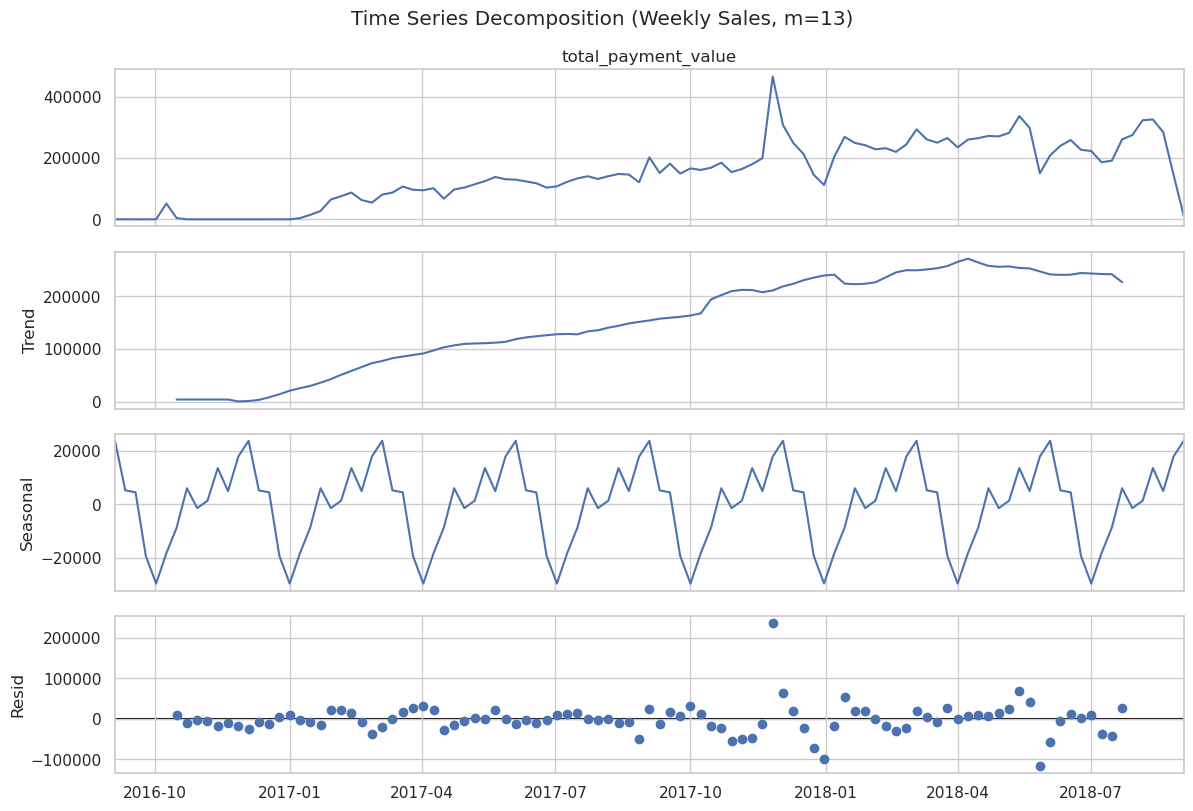

Time series decomposition plot generated.


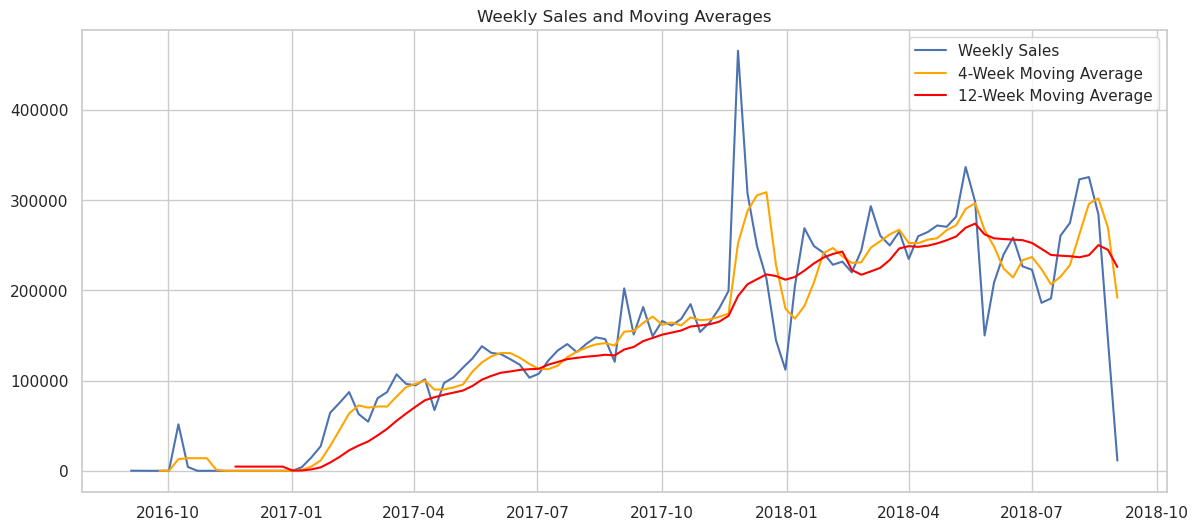


--- Part 1: Model Validation ---
ADF P-value: 0.5226236503809515
Splitting data: 84 train, 21 test weeks.

Attempting to fit SARIMAX model (m=13) for validation...

Plotting model diagnostics...


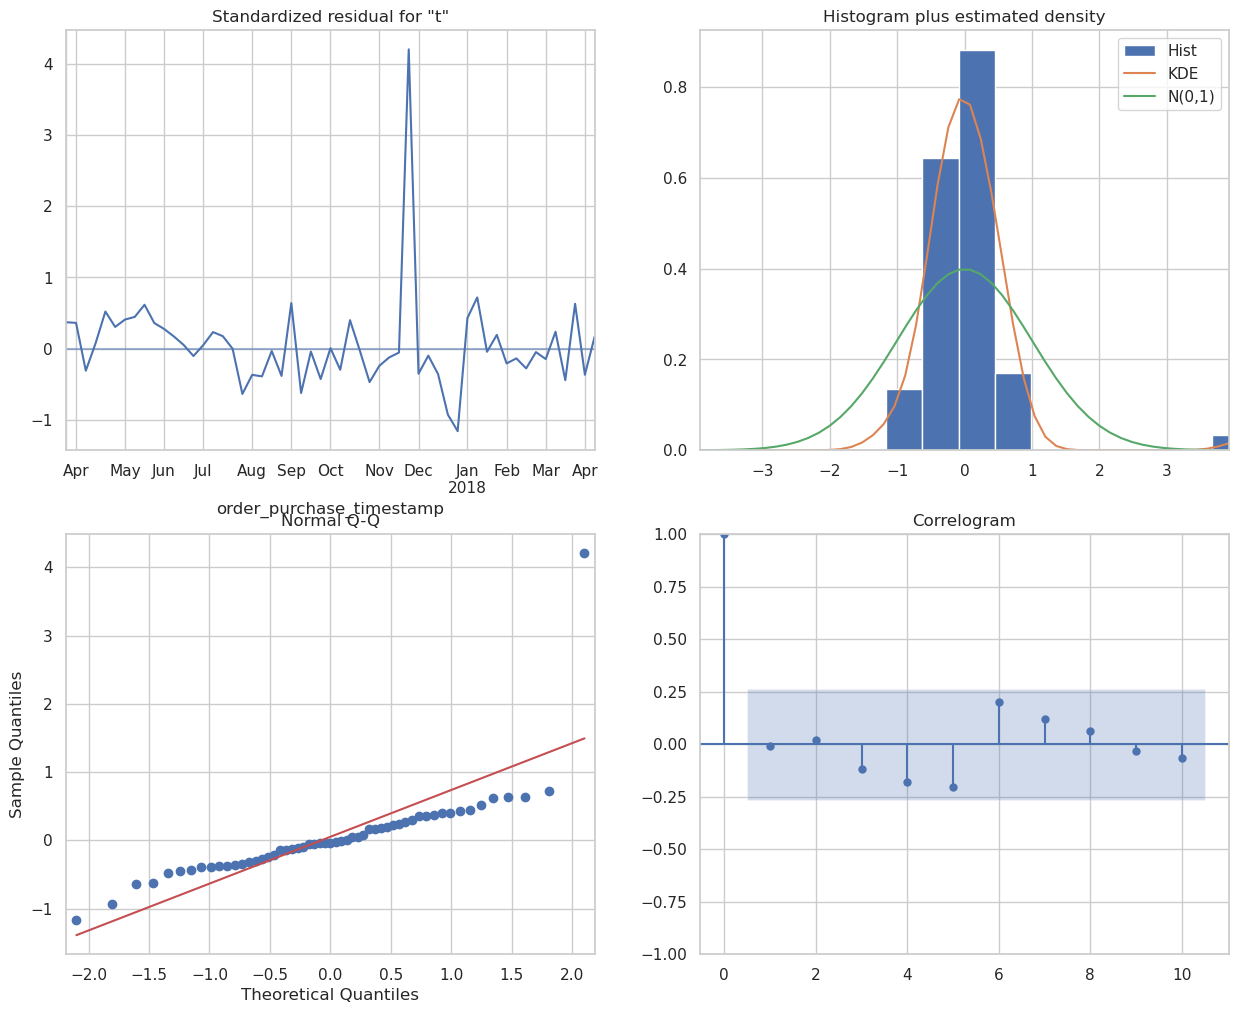


VALIDATION SARIMAX (m=13) RMSE: 146110.47


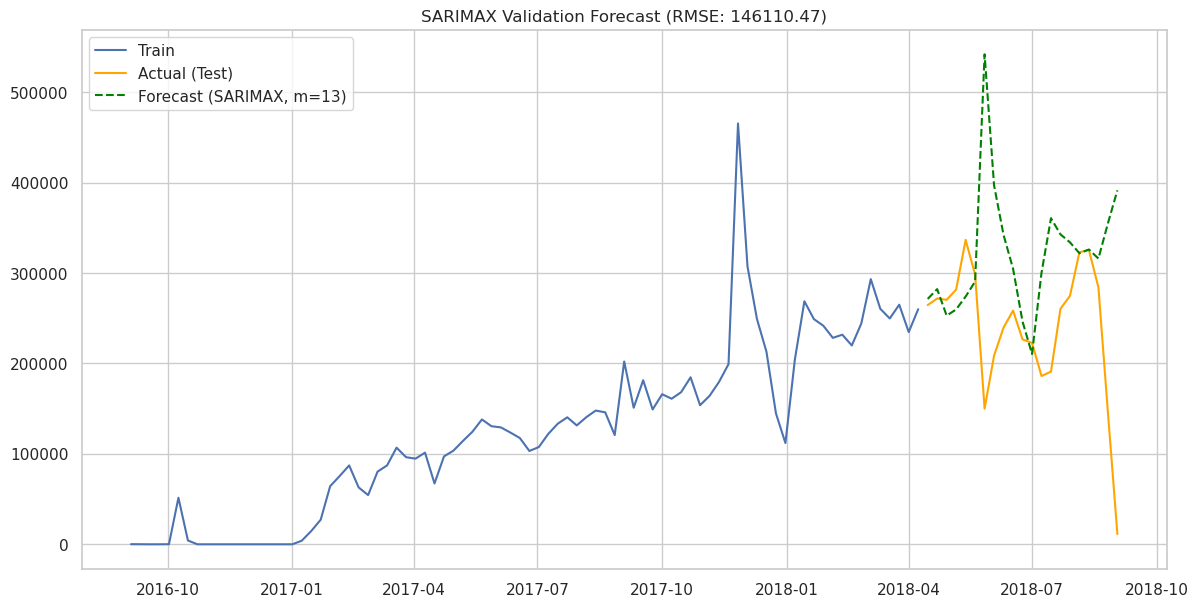

SARIMAX validation complete.

--- Part 2: Final Forecast for Planning ---
Re-training model on 100% of data to forecast the future...
Using SARIMAX for final forecast.

Forecast for the next 13 weeks:
            Forecasted_Sales
2018-09-09      95886.104944
2018-09-16     127753.982983
2018-09-23     164411.888258
2018-09-30     180584.967552
2018-10-07     142912.527657
2018-10-14     154307.579858
2018-10-21     150668.226375
2018-10-28     151054.874838
2018-11-04     147440.532637
2018-11-11     130135.594335
2018-11-18     135720.743510
2018-11-25     101949.917600
2018-12-02      80678.918166


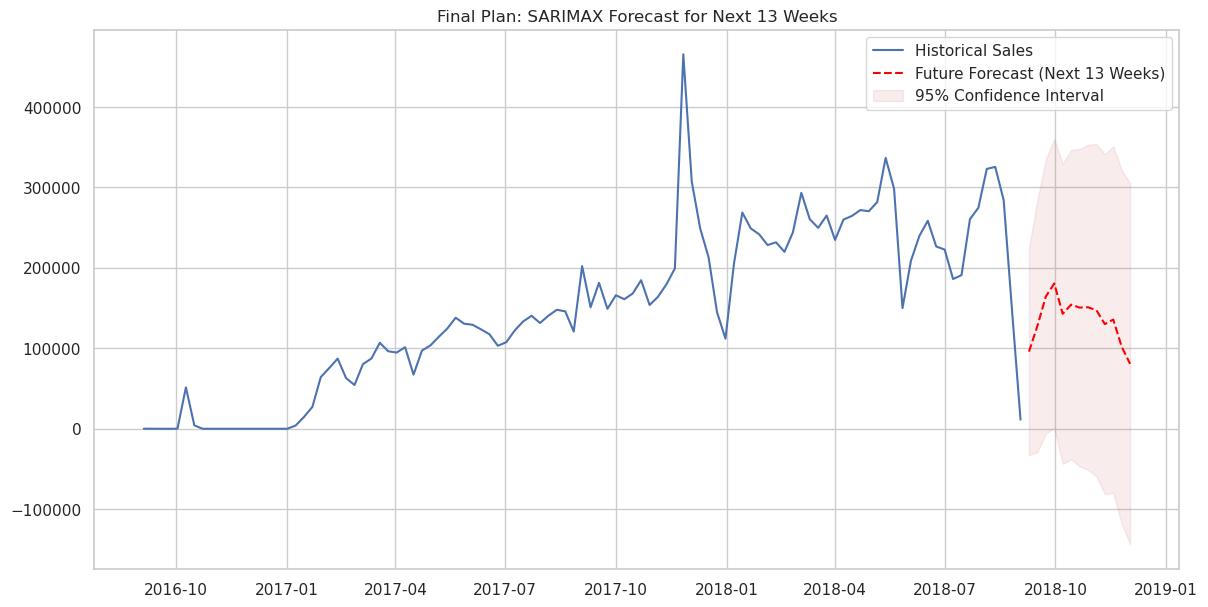


--- Time Series Analysis Finished ---


In [43]:
# --- 10. Time Series Analysis (Forecasting) ---

print("--- Starting Time Series Analysis ---")

# --- Prepare Time Series Data ---
sales_ts = order_level_df[['order_purchase_timestamp', 'total_payment_value']].copy()
sales_ts = sales_ts.set_index('order_purchase_timestamp')
weekly_sales = sales_ts['total_payment_value'].resample('W').sum()
weekly_sales = weekly_sales[:-1] # Remove last week (might be incomplete)
print(f"Time series prepared: {len(weekly_sales)} weeks of data.")

# --- Components of Time Series ---
try:
    decomposition = sm.tsa.seasonal_decompose(weekly_sales, model='additive', period=13)
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle('Time Series Decomposition (Weekly Sales, m=13)', y=1.02)
    plt.savefig('plot_06_ts_decomposition.png')
    plt.show()
    print("Time series decomposition plot generated.")
except ValueError as e:
    print(f"Could not decompose time series (perhaps too short): {e}")

# --- Technique: Moving Average (for visualization) ---
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales, label='Weekly Sales')
plt.plot(weekly_sales.rolling(window=4).mean(), label='4-Week Moving Average', color='orange')
plt.plot(weekly_sales.rolling(window=12).mean(), label='12-Week Moving Average', color='red')
plt.title('Weekly Sales and Moving Averages')
plt.legend()
plt.savefig('plot_07_moving_average.png')
plt.show()

# --- Part 1: Model Validation (Train/Test Split) ---
print("\n--- Part 1: Model Validation ---")
# Checking for stationarity (for 'd' parameter)
adf_result = adfuller(weekly_sales.dropna())
print(f'ADF P-value: {adf_result[1]}')
d = 1 if adf_result[1] > 0.05 else 0 # Use d=1 if non-stationary

# --- Train/Test Split ---
train_size = int(len(weekly_sales) * 0.8)
train, test = weekly_sales[:train_size], weekly_sales[train_size:]
print(f"Splitting data: {len(train)} train, {len(test)} test weeks.")

# --- Fit SARIMAX Model for Validation ---
try:
    print("\nAttempting to fit SARIMAX model (m=13) for validation...")
    validation_model = sm.tsa.statespace.SARIMAX(train,
                                                 order=(1, d, 1),
                                                 seasonal_order=(1, 1, 1, 13),
                                                 enforce_stationarity=False,
                                                 enforce_invertibility=False)
    
    validation_model_fit = validation_model.fit(disp=False)
    
    # --- Residual Diagnostics ---
    print("\nPlotting model diagnostics...")
    fig = validation_model_fit.plot_diagnostics(figsize=(15, 12))
    plt.savefig('plot_08a_sarima_diagnostics.png')
    plt.show()

    forecast = validation_model_fit.get_forecast(steps=len(test))
    forecast_mean = forecast.predicted_mean
    
    rmse = np.sqrt(mean_squared_error(test, forecast_mean))
    print(f"\nVALIDATION SARIMAX (m=13) RMSE: {rmse:.2f}")
    
    plt.figure(figsize=(14, 7))
    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Actual (Test)', color='orange')
    plt.plot(forecast_mean.index, forecast_mean, label='Forecast (SARIMAX, m=13)', color='green', linestyle='--')
    plt.title(f'SARIMAX Validation Forecast (RMSE: {rmse:.2f})')
    plt.legend()
    plt.savefig('plot_08b_sarima_validation.png')
    plt.show()
    print("SARIMAX validation complete.")

except Exception as e:
    print(f"\nCould not fit SARIMAX model for validation: {e}")
    print("Skipping to final forecast with Holt-Winters.")

# --- Part 2: Final Forecast for Planning ---
print("\n--- Part 2: Final Forecast for Planning ---")
print("Re-training model on 100% of data to forecast the future...")

# We will use the full `weekly_sales` dataset
try:
    # Use SARIMAX if it worked before, otherwise fall back
    if 'validation_model_fit' in locals():
        print("Using SARIMAX for final forecast.")
        final_model = sm.tsa.statespace.SARIMAX(weekly_sales, # Using all data
                                                 order=(1, d, 1),
                                                 seasonal_order=(1, 1, 1, 13),
                                                 enforce_stationarity=False,
                                                 enforce_invertibility=False)
        final_model_fit = final_model.fit(disp=False)
        model_name = "SARIMAX"
        
    else:
        # Fallback to Holt-Winters
        print("Using Holt-Winters for final forecast.")
        final_model = sm.tsa.ExponentialSmoothing(weekly_sales, # Using all data
                                                   seasonal_periods=13,
                                                   trend='add',
                                                   seasonal='add',
                                                   initialization_method='estimated')
        final_model_fit = final_model.fit()
        model_name = "Holt-Winters"
    
    # --- Forecast the next 13 weeks (one quarter) ---
    future_forecast = final_model_fit.get_forecast(steps=13)
    future_forecast_mean = future_forecast.predicted_mean
    
    # Get confidence intervals
    future_forecast_ci = future_forecast.conf_int()
    
    print("\nForecast for the next 13 weeks:")
    print(future_forecast_mean.to_frame(name='Forecasted_Sales'))

    # --- Plot the Final Forecast ---
    plt.figure(figsize=(14, 7))
    plt.plot(weekly_sales.index, weekly_sales, label='Historical Sales')
    plt.plot(future_forecast_mean.index, future_forecast_mean, label='Future Forecast (Next 13 Weeks)', color='red', linestyle='--')
    
    # Plot confidence interval
    plt.fill_between(future_forecast_ci.index,
                     future_forecast_ci.iloc[:, 0],
                     future_forecast_ci.iloc[:, 1], color='r', alpha=0.1, label='95% Confidence Interval')
    
    plt.title(f'Final Plan: {model_name} Forecast for Next 13 Weeks')
    plt.legend()
    plt.savefig('plot_09_final_forecast.png')
    plt.show()

except Exception as e:
    print(f"Could not generate final forecast: {e}")

print("\n--- Time Series Analysis Finished ---")


**Insight:** After validating our model, we re-trained it on 100% of the data. The final plot `(plot_09_final_forecast.png)` is the actionable plan. It shows the expected sales for the next 13 weeks. The wide "Confidence Interval" band correctly shows that while we expect the sales to follow this path, the high volatility means we must be prepared for it to be higher or lower in any given week. 

***

# 📊 Executive Summary — Olist E-Commerce Analysis (Brazil, 2016–2018)

### Overview
This analysis examines **96490 unique customer orders** from the **Olist Brazilian e-commerce dataset**, covering all stages of the data science workflow from cleaning and integration to descriptive, inferential, predictive, and prescriptive analytics.  
The goal: identify sales patterns, customer behavior segments, and actionable business strategies for Olist’s online marketplace.

---

### 1. Customer and Order Insights
- **Average Order Value (AOV):** R$160.54 (median R$105.28).  
- **Customer Concentration:** 42% of all orders come from **São Paulo (SP)**, followed by RJ (12%) and MG (11%).  
- **Review Scores:** Mean 4.11 / 5; 74% of reviews are 5-star — strong post-purchase satisfaction.  
- **Installment Behavior:** Most buyers use ≤ 3 installments; review score dips slightly for 8–10 installments, suggesting potential payment friction.

**Managerial takeaway:**  
Focus logistics and marketing efforts on SP and RJ; maintain short-installment payment options to sustain high satisfaction.

---

### 2. Segmentation (K-Means, k = 3)
| Cluster | Description | Share | Spend Pattern |
|----------|--------------|--------|----------------|
| 0 | One-time low spenders | ~85% | Low frequency, low value |
| 1 | High spenders (occasional) | ~10% | High AOV, few orders |
| 2 | Repeat low spenders | ~5% | Low AOV, high frequency |

**Managerial takeaway:**  
Prioritize **Cluster 1** for loyalty and **Cluster 2** for repeat-purchase incentives.

---

### 3. Hypothesis Testing Highlights
- **Review score > 4.0 (p < 0.001)** → customer satisfaction significantly above neutral.  
- **SP vs RJ AOV difference significant (p < 0.001)** → RJ customers spend ~16% more.  
- **Customer segment ↔ payment type dependent (p < 0.001)** → cluster-based payment preferences exist.  
- **Review score varies by top categories (p < 0.001)** → “Bed & Bath” vs “Health & Beauty” differ materially.

---

### 4. Recommender System (Prescriptive)
Frequent category bundles (lift > 1.5):
- **Bed & Bath ⇄ Home Comfort** (lift = 3.15)  
- **Health & Beauty ⇄ Perfumery** (lift = 4.79)  
- **Watches & Gifts ⇄ Audio** (lift = 18.15)

**Action:**  
Create cross-promotion bundles and targeted upselling campaigns using these category pairs.

---

### 5. Time-Series Forecast (Predictive)
- **Model:** SARIMAX (1, 1, 1)(1, 1, 1, 13)  
- **Validation RMSE:** ≈ R$146 k  
- **Next-Quarter Forecast:** stable growth with weekly fluctuations; expected range R$80 k–R$180 k per week.  
- **Uncertainty:** wide 95% CI — monitor real-time weekly sales for model recalibration.

**Action:**  
Use forecast for inventory and ad-budget planning; consider regional scaling of campaigns around predicted peaks.

---

### 6. Key Recommendations
✅ Strengthen operations in **SP and RJ** (core revenue regions).  
✅ Develop **repeat-buyer programs** for Cluster 2 (5% base but high frequency).  
✅ Launch **category bundle promotions** identified by Apriori.  
✅ Track **forecast deviations weekly**; retrain SARIMAX every quarter.  
✅ Add **visual dashboard** with regional maps, sales trends, and cluster metrics.

---

**Prepared:** November 2025  
**Authors:** Muhir Kapoor
**Purpose:** Strategic business insight and forecasting readiness report.
